In [45]:
import numpy as np

Vamos a escribir un solucionador de la ecuación de movimiento:

$$
\frac{d^2 \tilde{x}_L}{d\tau^2} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

Equivale:
$$
\frac{d\tilde{x}_L}{d\tau} = \tilde{U}\\
\frac{d\tilde{U}_L}{d\tau} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

In [55]:
def edm_espacio_tiempo(tau ,Ys , alpha):
    
    #* Ys : contiene todas las variables de movimiento
    #* t,x, y, z, Ut, Ux, Uy, Uz

    T , x, y, z, Ut ,Ux ,Uy ,Uz = Ys

    #* Ecuacion de movimiento
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    #? ¿ cuanto vales lascomponente de A ?
    #* La acelaracio propia

    Apropia = np.array([0 , alpha , 0 , 0])

    #* La aceleracion en elsistaema de coordenadas del observador 

    gamma = Ut
    beta = Ux / Ut

    Lambda = np.array([
        [gamma , gamma * beta , 0 , 0],
        [gamma * beta , gamma , 0 , 0],
        [0 , 0 , 1 , 0],
        [0 , 0 , 0 , 1]
    ])

    A_tierra = Lambda @ Apropia

    #* Entonces

    dUt_dtau = A_tierra[0]
    dUx_dtau = A_tierra[1]
    dUy_dtau = A_tierra[2]
    dUz_dtau = A_tierra[3]

    #

    return dT_dtau , dx_dtau , dy_dtau , dz_dtau , dUt_dtau , dUx_dtau , dUy_dtau , dUz_dtau

# Condinciones iniciales

condiciones iniciales expresadas en coordenadas espacio-temporales:

In [47]:
#* posición inicial 
t = 0 
x = 0
y = 0
z = 0

#* velocidad inicial
vx = 0
vy = 0
vz = 0


condiciones iniciales expresadas en cuadrivectores:

In [48]:
c = 1 #* velocidad de la luz en unidades Relativistas
c_SI = 299792458 #* velocidad de la luz en unidades SI
 
UT = 365.25 * 86400 
UL = c_SI * UT
UV = UL / UT
UA= UL / (UT)**2

UT , UL , UV , UA

(31557600.0, 9460730472580800.0, 299792458.0, 9.499849735087587)

In [49]:
T = c * t
#! x . y , z son las mismas 

gamma = 1 / np.sqrt(1 - (vx**2 + vy**2 + vz**2) / c**2)   

Ut = gamma * c
Ux = gamma * vx
Uy = gamma * vy
Uz = gamma * vz

Y0 = np.array([T , x , y , z , Ut, Ux , Uy , Uz])

alpha = 9.8 / UA

edm_espacio_tiempo(0 , Y0 , alpha)

1.0 0.0


(np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0315952644812698),
 np.float64(0.0),
 np.float64(0.0))

In [50]:
from scipy.integrate import solve_ivp

In [56]:
alpha = 9.8 / UA
taus = np.linspace(0 , 4 , 100)
solucion = solve_ivp(edm_espacio_tiempo, (taus[0] , taus[-1]) , Y0 , args = (alpha,) , t_eval = taus)

In [57]:
taus = solucion.t
Ts = solucion.y[0]
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

Uts = solucion.y[4]
Uxs = solucion.y[5]
Uys = solucion.y[6]
Uzs = solucion.y[7]

## Convertir las medidas espacio-temporales en medidas espaciales y temporales 

In [58]:
ts = Ts / c
gammas = Uts / c
vxs = Uxs / gammas
vys = Uys / gammas
vzs = Uzs / gammas


In [42]:
ts

array([0.00000000e+00, 4.14090343e-02, 8.89806664e-02, 1.49858448e-01,
       2.33010291e-01, 3.50987696e-01, 5.21304891e-01, 7.68976768e-01,
       1.13198054e+00, 1.66409919e+00, 2.44216335e+00, 3.58461241e+00,
       5.26588530e+00, 7.73231477e+00, 1.13382684e+01, 1.66394733e+01,
       2.44443833e+01, 3.58929580e+01, 5.26251664e+01, 7.72200837e+01,
       1.13450324e+02, 1.66598820e+02, 2.44271143e+02, 3.58354651e+02,
       5.26496495e+02, 7.73226846e+02, 1.13390454e+03, 1.66305821e+03,
       2.44319071e+03, 3.58847813e+03, 5.26373375e+03, 7.71831937e+03,
       1.13370961e+04, 1.66527527e+04, 2.44350116e+04, 3.58230713e+04,
       5.26065132e+04, 7.72766600e+04, 1.13428338e+05, 1.66275403e+05,
       2.44106832e+05, 3.58611185e+05, 5.26515808e+05, 7.71820159e+05,
       1.13274199e+06, 1.66428086e+06, 2.44384903e+06, 3.58280303e+06,
       5.25652825e+06, 7.72328083e+06, 1.13424160e+07, 1.66319267e+07,
       2.43943131e+07, 3.58388453e+07, 5.26386089e+07, 7.72089660e+07,
      

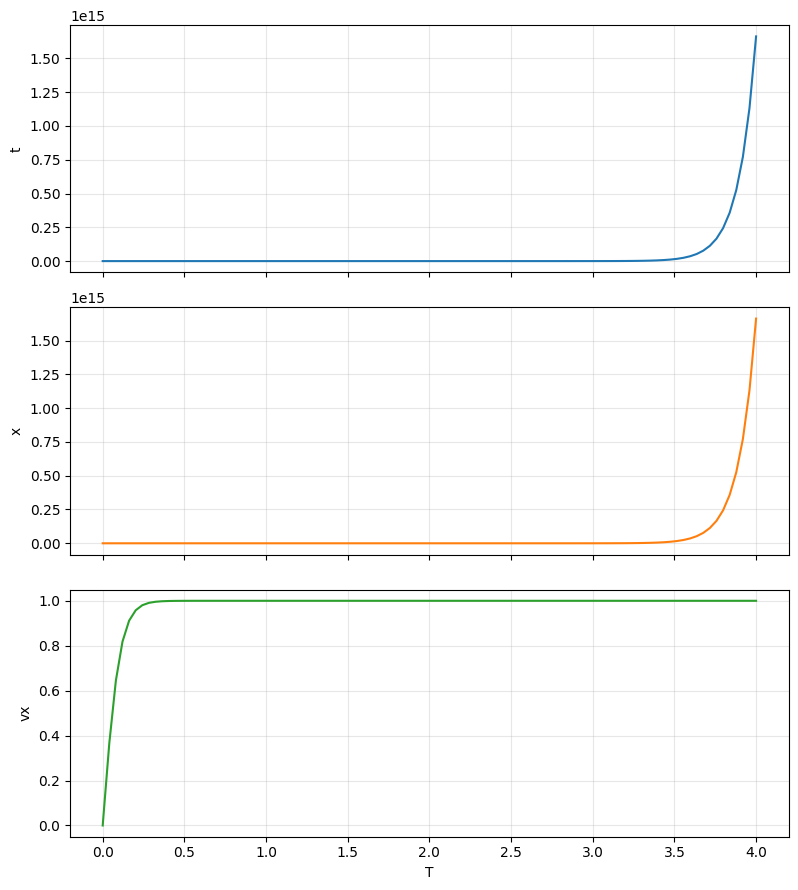

In [34]:
import matplotlib.pyplot as plt

# Series desde la solución numérica

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs[0].plot(taus, ts)
axs[0].set_ylabel("t")
axs[0].grid(True, alpha=0.3)

axs[1].plot(taus, xs, color="tab:orange")
axs[1].set_ylabel("x")
axs[1].grid(True, alpha=0.3)

axs[2].plot(taus, vxs, color="tab:green")
axs[2].set_ylabel("vx")
axs[2].set_xlabel("T")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
alpha

1.0315952644812698

alpha: 1.0315952644812698
UA: 9.499849735087587
tau[min,max]: 0.0 4.0
Ts[min,max]: 0.0 30.020056391078498
ts[min,max]: 0.0 30.020056391078498
gamma[min,max]: 1.0 30.984892101923222
vx[min,max]: 0.0 0.9994725142378355
